In [1]:
!pip install networkx matplotlib


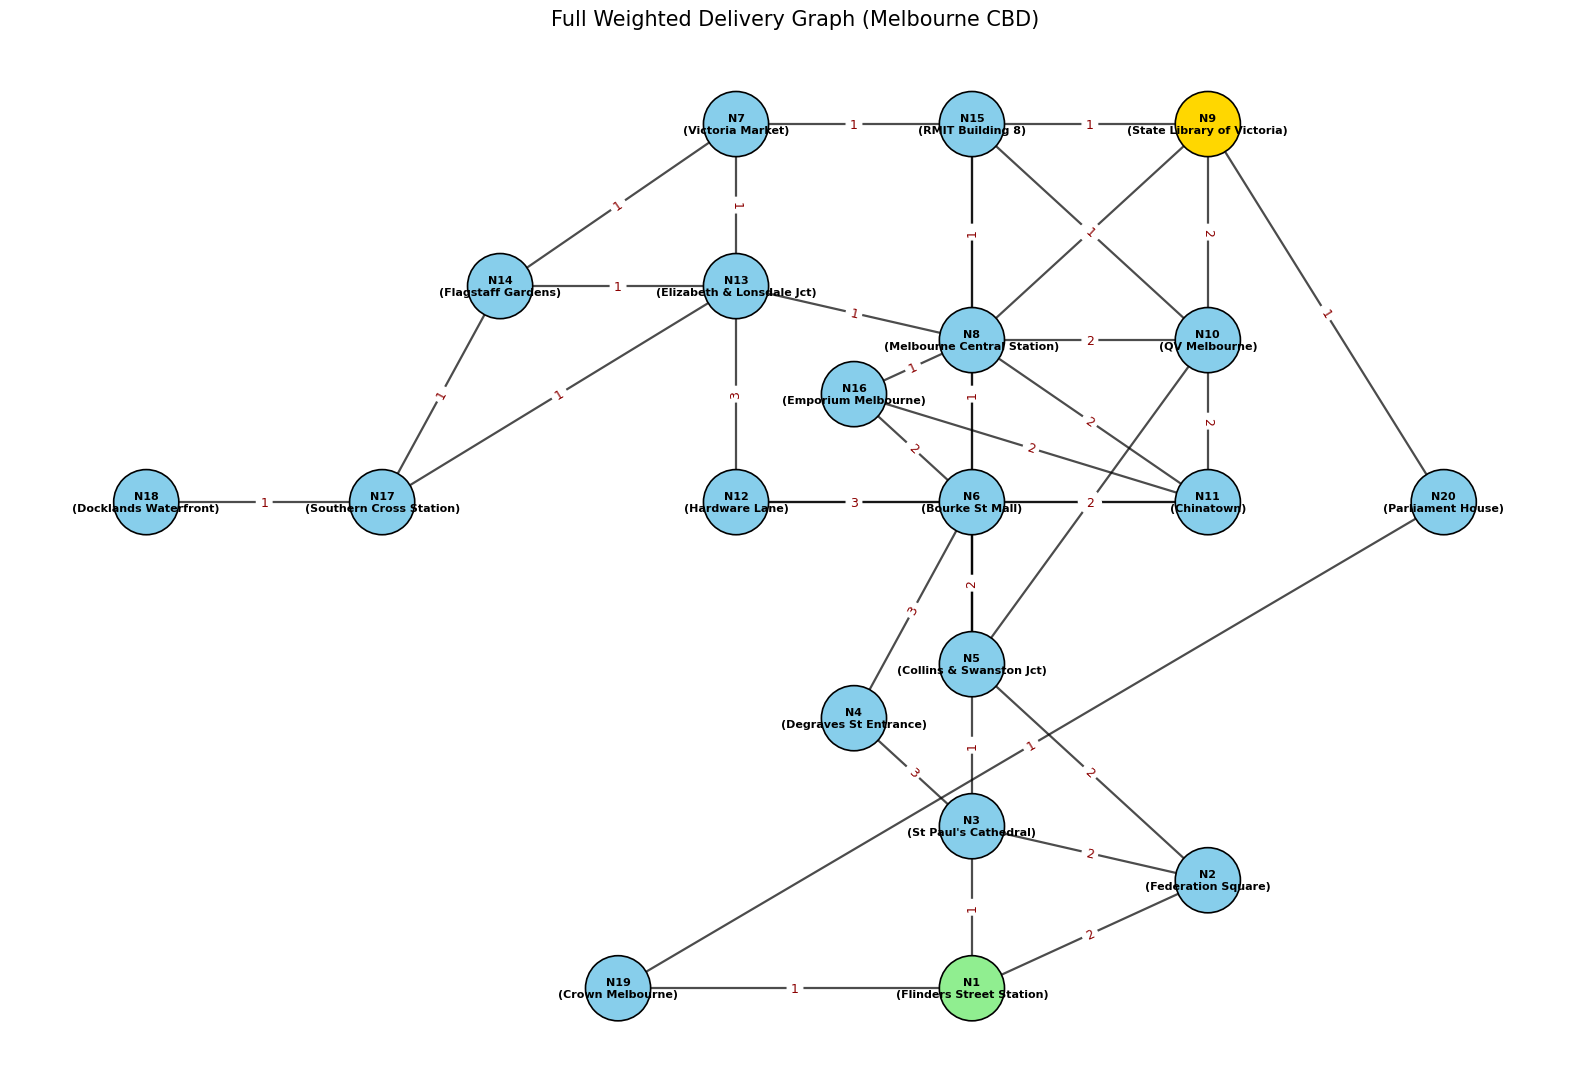

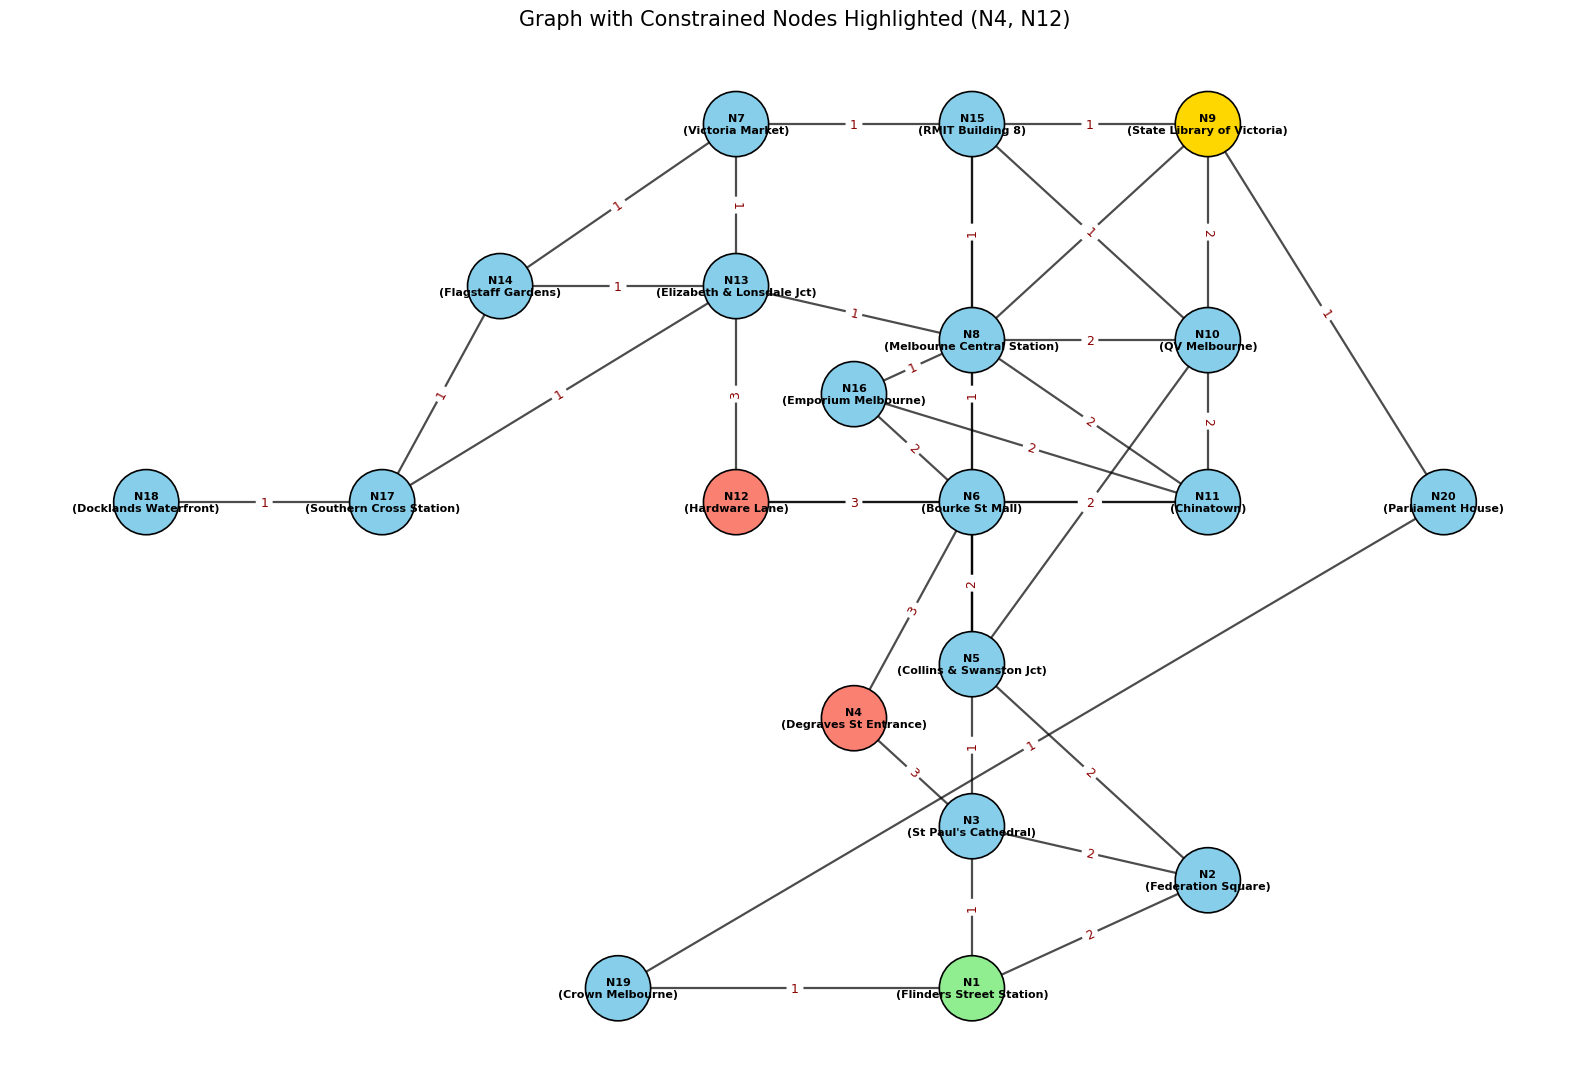

Computed shortest path: N1 -> N19 -> N20 -> N9
Total path cost: 3


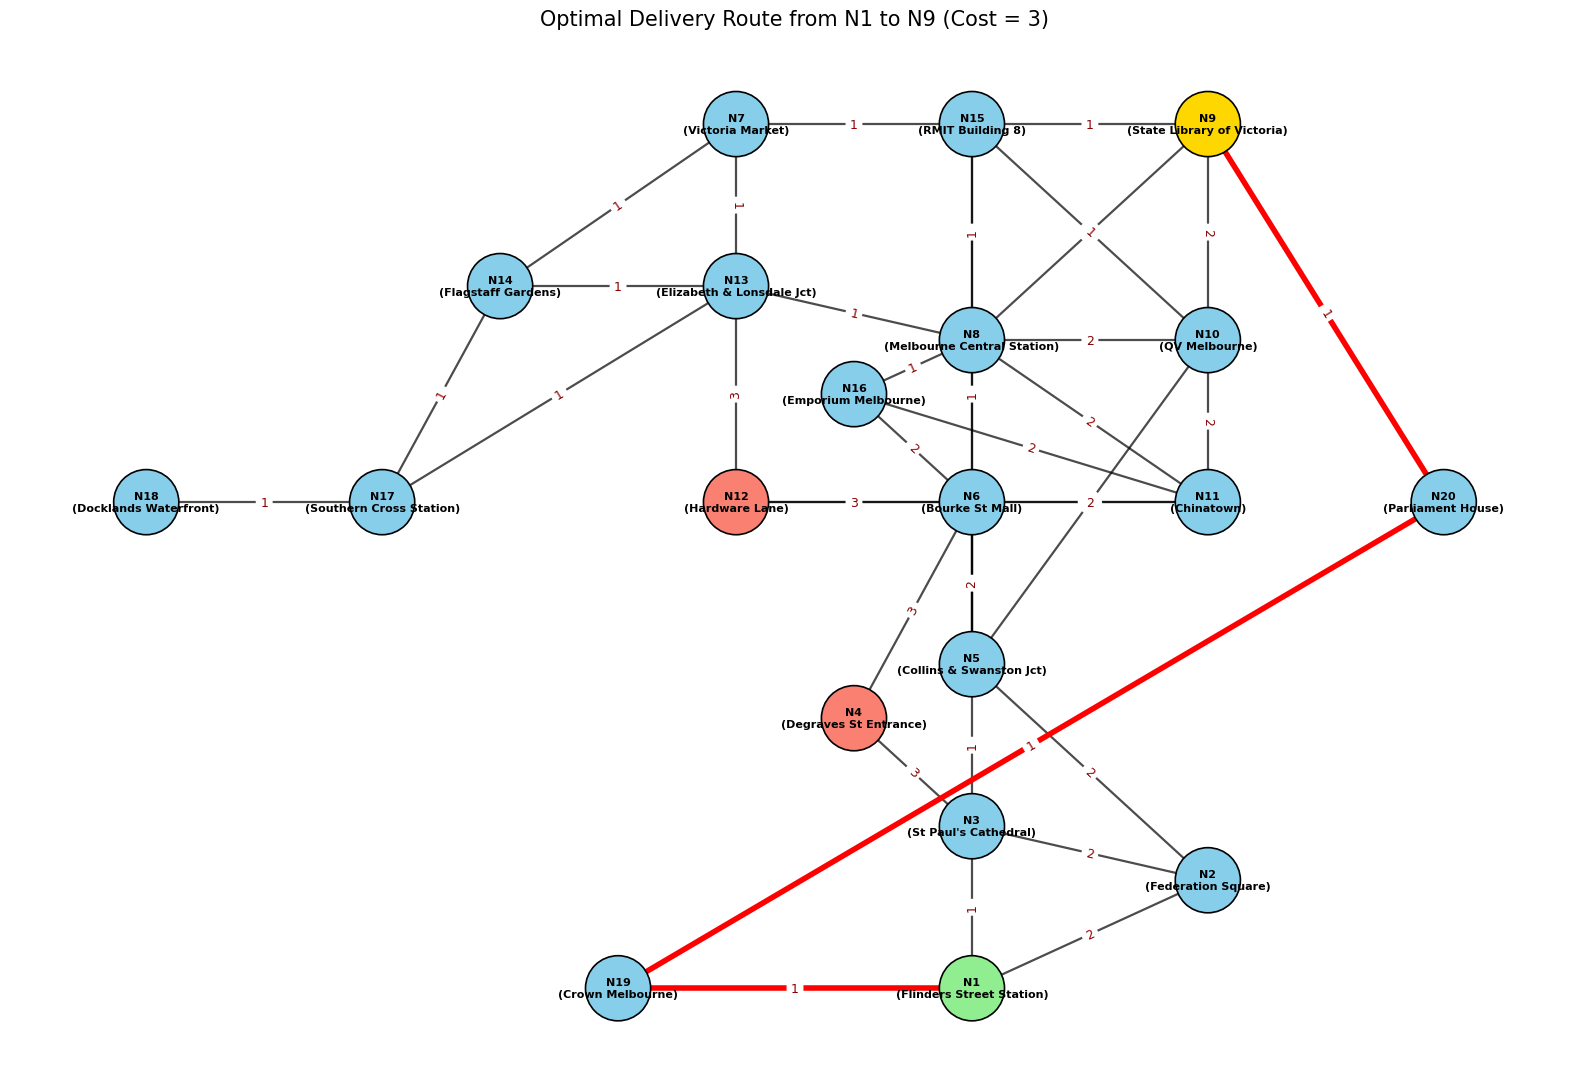


Explanation:
1. The graph is built as an undirected weighted graph using NetworkX.
2. Each node represents a Melbourne CBD landmark.
3. Each edge represents a feasible path segment, and the weight is the path cost.
4. Constrained nodes N4 and N12 are highlighted because they represent narrow or truck-unfriendly areas.
5. The shortest path from N1 to N9 is computed using the weighted shortest path method in NetworkX.
6. The code saves three PNG files:
   - 1_full_weighted_graph.png
   - 2_constrained_nodes.png
   - 3_shortest_path.png


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Landmark data
# Each landmark is treated as a node in the delivery graph.
# -----------------------------------------
nodes = {
    "N1": "Flinders Street Station",
    "N2": "Federation Square",
    "N3": "St Paul's Cathedral",
    "N4": "Degraves St Entrance",
    "N5": "Collins & Swanston Jct",
    "N6": "Bourke St Mall",
    "N7": "Victoria Market",
    "N8": "Melbourne Central Station",
    "N9": "State Library of Victoria",
    "N10": "QV Melbourne",
    "N11": "Chinatown",
    "N12": "Hardware Lane",
    "N13": "Elizabeth & Lonsdale Jct",
    "N14": "Flagstaff Gardens",
    "N15": "RMIT Building 8",
    "N16": "Emporium Melbourne",
    "N17": "Southern Cross Station",
    "N18": "Docklands Waterfront",
    "N19": "Crown Melbourne",
    "N20": "Parliament House"
}

# -----------------------------------------
# 2. Weighted path data
# Each edge shows a possible route between two landmarks.
# The weight represents travel difficulty or movement cost.
# -----------------------------------------
edges = [
    ("N1", "N2", 2),
    ("N1", "N3", 1),
    ("N1", "N19", 1),
    ("N2", "N3", 2),
    ("N2", "N5", 2),
    ("N3", "N4", 3),
    ("N3", "N5", 1),
    ("N4", "N6", 3),
    ("N5", "N6", 2),
    ("N5", "N8", 1),
    ("N5", "N10", 1),
    ("N5", "N15", 1),
    ("N6", "N11", 2),
    ("N6", "N12", 3),
    ("N6", "N16", 2),
    ("N7", "N13", 1),
    ("N7", "N14", 1),
    ("N7", "N15", 1),
    ("N8", "N9", 1),
    ("N8", "N10", 2),
    ("N8", "N11", 2),
    ("N8", "N13", 1),
    ("N8", "N15", 1),
    ("N8", "N16", 1),
    ("N9", "N10", 2),
    ("N9", "N15", 1),
    ("N10", "N11", 2),
    ("N10", "N15", 1),
    ("N11", "N12", 3),
    ("N11", "N16", 2),
    ("N12", "N13", 3),
    ("N13", "N14", 1),
    ("N13", "N17", 1),
    ("N14", "N17", 1),
    ("N17", "N18", 1),
    ("N19", "N20", 1),
    ("N20", "N9", 1)
]

# -----------------------------------------
# 3. Manual node positions
# These positions are only used to make the graph easier to read.
# -----------------------------------------
pos = {
    "N1": (5, 0),
    "N19": (2, 0),
    "N2": (7, 1),
    "N3": (5, 1.5),
    "N4": (4, 2.5),
    "N5": (5, 3),
    "N6": (5, 4.5),
    "N12": (3, 4.5),
    "N11": (7, 4.5),
    "N20": (9, 4.5),
    "N17": (0, 4.5),
    "N18": (-2, 4.5),
    "N16": (4, 5.5),
    "N8": (5, 6),
    "N10": (7, 6),
    "N13": (3, 6.5),
    "N14": (1, 6.5),
    "N7": (3, 8),
    "N15": (5, 8),
    "N9": (7, 8)
}

# -----------------------------------------
# 4. Build the weighted graph
# This stores both landmark connections and path costs.
# -----------------------------------------
G = nx.Graph()

# Add each landmark as a node
for node_id, landmark_name in nodes.items():
    G.add_node(node_id, name=landmark_name)

# Add each path with its travel cost
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# -----------------------------------------
# 5. Labels and key settings
# N4 and N12 are marked as constrained locations.
# -----------------------------------------
edge_labels = nx.get_edge_attributes(G, "weight")
constrained_nodes = {"N4", "N12"}
start_node = "N1"
goal_node = "N9"

# Show both the node ID and landmark name on the figure
node_labels = {node_id: f"{node_id}\n({landmark})" for node_id, landmark in nodes.items()}

# -----------------------------------------
# 6. Drawing function
# This function is reused to generate different figures
# for the report.
# -----------------------------------------
def draw_delivery_graph(
    graph,
    positions,
    title,
    filename,
    highlight_constrained=False,
    highlight_path=None
):
    plt.figure(figsize=(16, 11))

    # Choose node colors based on role in the graph
    node_colors = []
    for node in graph.nodes():
        if node == start_node:
            node_colors.append("lightgreen")   # Start node
        elif node == goal_node:
            node_colors.append("gold")         # Goal node
        elif highlight_constrained and node in constrained_nodes:
            node_colors.append("salmon")       # Constrained node
        else:
            node_colors.append("skyblue")      # Regular node

    # Draw all available path segments first
    nx.draw_networkx_edges(
        graph,
        positions,
        width=1.6,
        alpha=0.7
    )

    # Highlight the selected route if provided
    if highlight_path:
        path_edges = list(zip(highlight_path[:-1], highlight_path[1:]))
        nx.draw_networkx_edges(
            graph,
            positions,
            edgelist=path_edges,
            width=4,
            edge_color="red"
        )

    # Draw landmark nodes
    nx.draw_networkx_nodes(
        graph,
        positions,
        node_size=2200,
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.2
    )

    # Add node labels for readability
    nx.draw_networkx_labels(
        graph,
        positions,
        labels=node_labels,
        font_size=8,
        font_weight="bold"
    )

    # Show edge costs on the graph
    nx.draw_networkx_edge_labels(
        graph,
        positions,
        edge_labels=edge_labels,
        font_size=9,
        font_color="darkred"
    )

    plt.title(title, fontsize=15)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------------------
# 7. Figure 1: full weighted graph
# -----------------------------------------
draw_delivery_graph(
    graph=G,
    positions=pos,
    title="Full Weighted Delivery Graph (Melbourne CBD)",
    filename="1_full_weighted_graph.png",
    highlight_constrained=False
)

# -----------------------------------------
# 8. Figure 2: constrained nodes highlighted
# This figure makes truck-unfriendly locations easier to identify.
# -----------------------------------------
draw_delivery_graph(
    graph=G,
    positions=pos,
    title="Graph with Constrained Nodes Highlighted (N4, N12)",
    filename="2_constrained_nodes.png",
    highlight_constrained=True
)

# -----------------------------------------
# 9. Figure 3: weighted shortest path from N1 to N9
# The weighted method is used because route cost matters here.
# -----------------------------------------
shortest_path = nx.shortest_path(G, source=start_node, target=goal_node, weight="weight")
shortest_cost = nx.shortest_path_length(G, source=start_node, target=goal_node, weight="weight")

print("Computed shortest path:", " -> ".join(shortest_path))
print("Total path cost:", shortest_cost)

draw_delivery_graph(
    graph=G,
    positions=pos,
    title=f"Optimal Delivery Route from {start_node} to {goal_node} (Cost = {shortest_cost})",
    filename="3_shortest_path.png",
    highlight_constrained=True,
    highlight_path=shortest_path
)

# -----------------------------------------
# 10. Short explanation
# This helps summarise the output after the figures are created.
# -----------------------------------------
print("\nExplanation:")
print("1. The graph is built as an undirected weighted graph using NetworkX.")
print("2. Each node represents a Melbourne CBD landmark.")
print("3. Each edge represents a feasible path segment, and the weight is the path cost.")
print("4. Constrained nodes N4 and N12 are highlighted because they represent narrow or truck-unfriendly areas.")
print("5. The shortest path from N1 to N9 is computed using the weighted shortest path method in NetworkX.")
print("6. The code saves three PNG files:")
print("   - 1_full_weighted_graph.png")
print("   - 2_constrained_nodes.png")
print("   - 3_shortest_path.png")

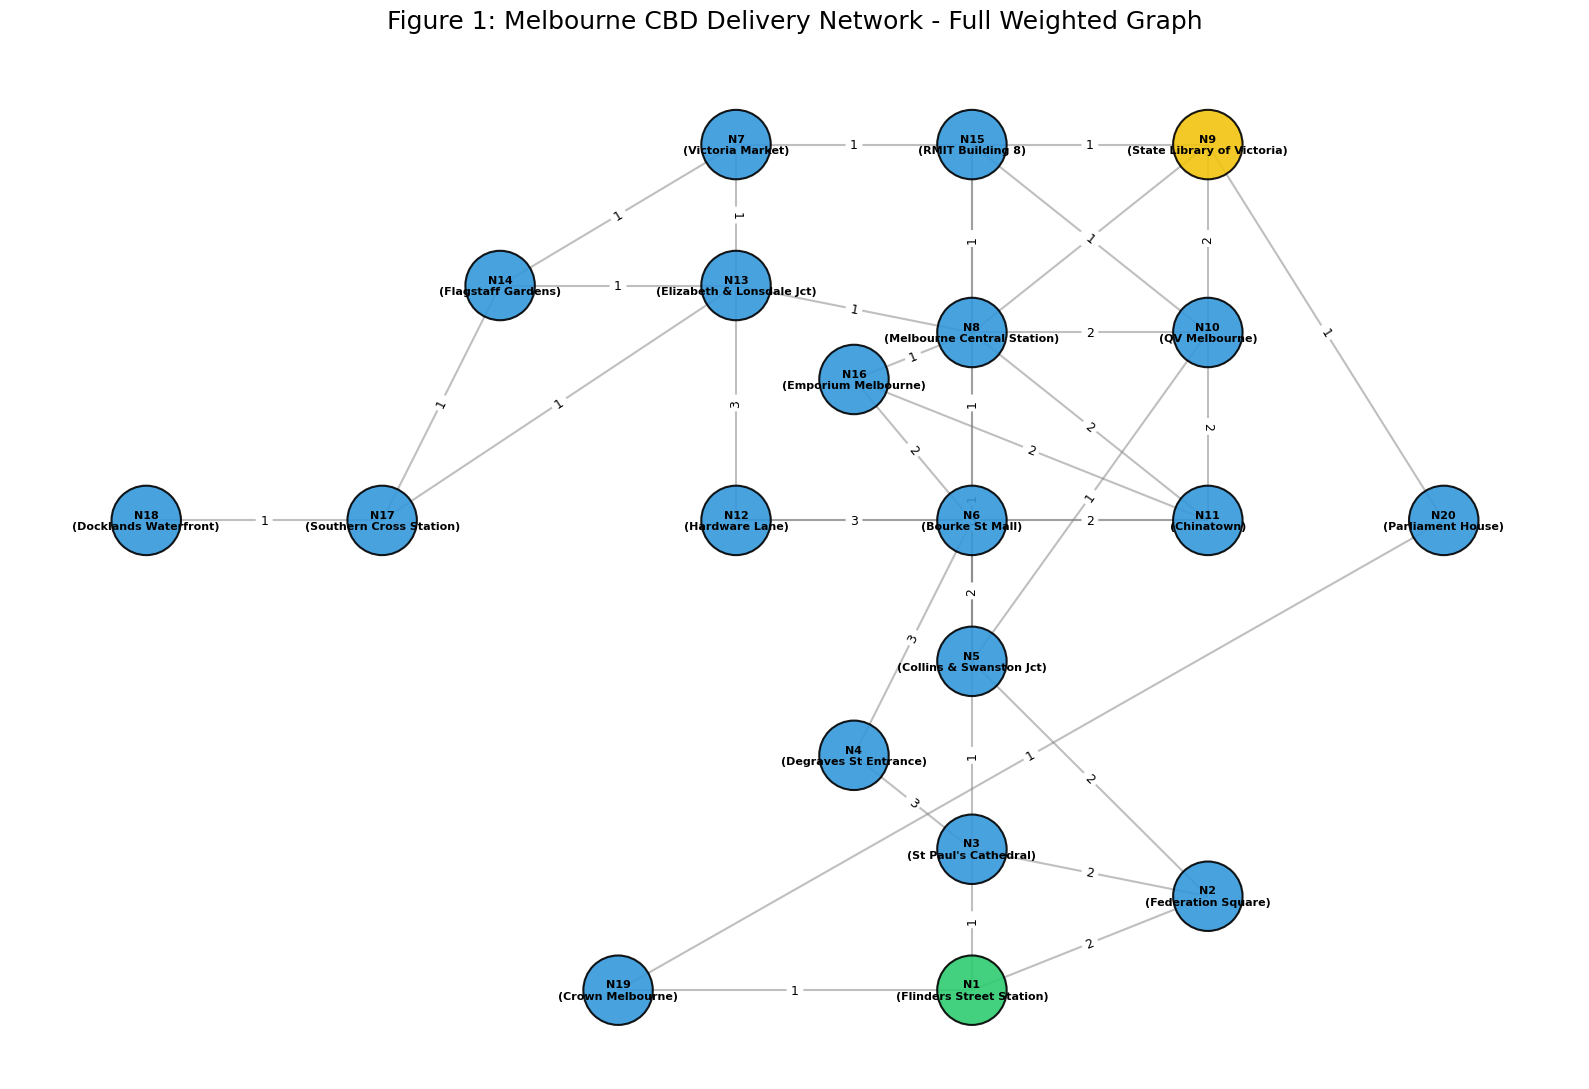

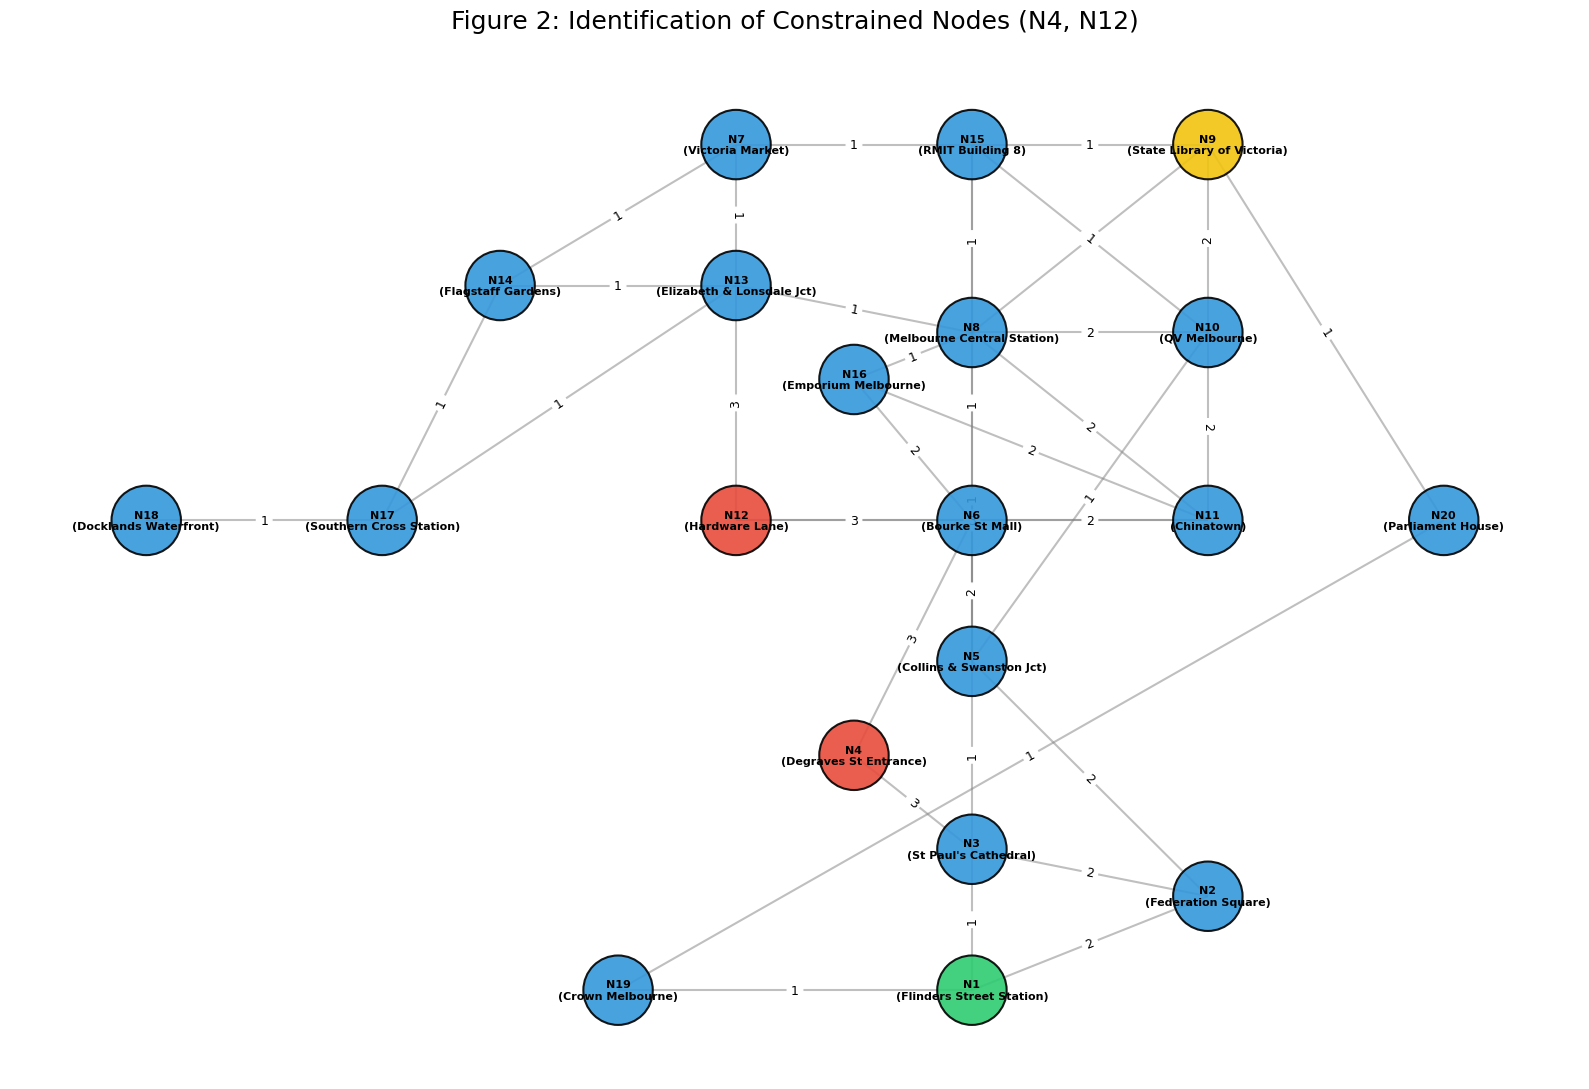

Optimal Path: N1 -> N19 -> N20 -> N9 | Total Cost: 3


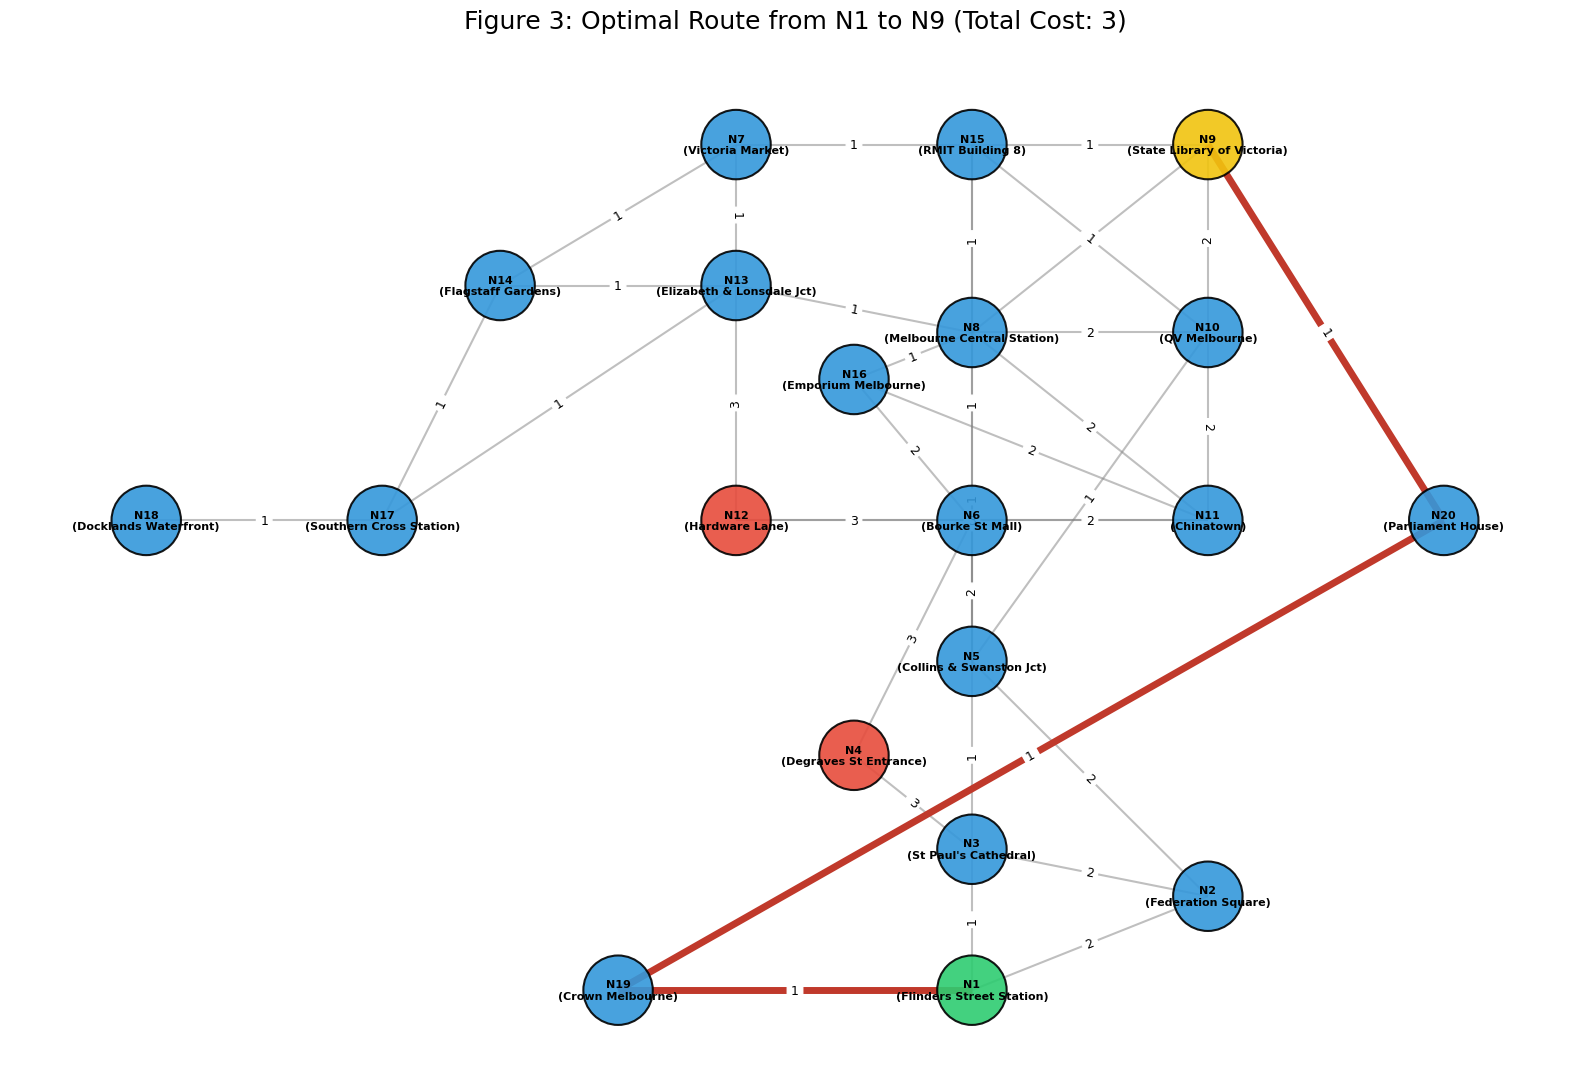

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# 1. Define data (landmarks and weighted edges)
# -----------------------------
nodes = {
    "N1": "Flinders Street Station", "N2": "Federation Square", "N3": "St Paul's Cathedral",
    "N4": "Degraves St Entrance", "N5": "Collins & Swanston Jct", "N6": "Bourke St Mall",
    "N7": "Victoria Market", "N8": "Melbourne Central Station", "N9": "State Library of Victoria",
    "N10": "QV Melbourne", "N11": "Chinatown", "N12": "Hardware Lane",
    "N13": "Elizabeth & Lonsdale Jct", "N14": "Flagstaff Gardens", "N15": "RMIT Building 8",
    "N16": "Emporium Melbourne", "N17": "Southern Cross Station", "N18": "Docklands Waterfront",
    "N19": "Crown Melbourne", "N20": "Parliament House"
}

# Edge list with weights (travel cost between locations)
edges = [
    ("N1", "N2", 2), ("N1", "N3", 1), ("N1", "N19", 1), ("N2", "N3", 2), ("N2", "N5", 2),
    ("N3", "N4", 3), ("N3", "N5", 1), ("N4", "N6", 3), ("N5", "N6", 2), ("N5", "N8", 1),
    ("N5", "N10", 1), ("N5", "N15", 1), ("N6", "N11", 2), ("N6", "N12", 3), ("N6", "N16", 2),
    ("N7", "N13", 1), ("N7", "N14", 1), ("N7", "N15", 1), ("N8", "N9", 1), ("N8", "N10", 2),
    ("N8", "N11", 2), ("N8", "N13", 1), ("N8", "N15", 1), ("N8", "N16", 1), ("N9", "N10", 2),
    ("N9", "N15", 1), ("N10", "N11", 2), ("N10", "N15", 1), ("N11", "N12", 3), ("N11", "N16", 2),
    ("N12", "N13", 3), ("N13", "N14", 1), ("N13", "N17", 1), ("N14", "N17", 1), ("N17", "N18", 1),
    ("N19", "N20", 1), ("N20", "N9", 1)
]

# -----------------------------
# 2. Set node positions (approximate CBD layout)
# -----------------------------
pos = {
    "N1": (5, 0), "N2": (7, 1), "N19": (2, 0),
    "N3": (5, 1.5), "N4": (4, 2.5), "N5": (5, 3.5),
    "N6": (5, 5), "N12": (3, 5), "N11": (7, 5), "N20": (9, 5),
    "N8": (5, 7), "N10": (7, 7), "N16": (4, 6.5), "N13": (3, 7.5),
    "N17": (0, 5), "N14": (1, 7.5), "N18": (-2, 5),
    "N7": (3, 9), "N9": (7, 9), "N15": (5, 9)
}

# -----------------------------
# 3. Graph creation and drawing function
# -----------------------------
def draw_assignment_graph(title, filename, highlight_constrained=False, highlight_path=None):
    
    # Create graph
    G = nx.Graph()
    for u, v, w in edges:
        G.add_edge(u, v, weight=w)

    plt.figure(figsize=(16, 11))
    
    # Assign node colors
    node_colors = []
    for node in G.nodes():
        if node == "N1":
            node_colors.append("#2ecc71")   # Start node
        elif node == "N9":
            node_colors.append("#f1c40f")   # Goal node
        elif highlight_constrained and node in {"N4", "N12"}:
            node_colors.append("#e74c3c")   # Constrained nodes
        else:
            node_colors.append("#3498db")   # Normal nodes

    # Draw all edges
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, edge_color="gray")
    
    # Highlight shortest path if provided
    if highlight_path:
        path_edges = list(zip(highlight_path, highlight_path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=5, edge_color="#c0392b")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color=node_colors,
                           edgecolors="black", linewidths=1.5, alpha=0.9)

    # Draw node labels (ID + name)
    labels = {node_id: f"{node_id}\n({nodes[node_id]})" for node_id in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold')

    # Draw edge weights
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=9)

    plt.title(title, fontsize=18, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    return G

# -----------------------------
# 4. Run scenarios and save results
# -----------------------------

# Scenario 1: Full weighted graph
G_obj = draw_assignment_graph(
    "Figure 1: Melbourne CBD Delivery Network - Full Weighted Graph",
    "1_full_graph.png"
)

# Scenario 2: Highlight constrained nodes
draw_assignment_graph(
    "Figure 2: Identification of Constrained Nodes (N4, N12)",
    "2_constrained_graph.png",
    highlight_constrained=True
)

# Scenario 3: Compute shortest path
shortest_path = nx.shortest_path(G_obj, source="N1", target="N9", weight="weight")
shortest_cost = nx.shortest_path_length(G_obj, source="N1", target="N9", weight="weight")

# Print result
print(f"Optimal Path: {' -> '.join(shortest_path)} | Total Cost: {shortest_cost}")

# Visualise shortest path
draw_assignment_graph(
    f"Figure 3: Optimal Route from N1 to N9 (Total Cost: {shortest_cost})",
    "3_optimal_path.png",
    highlight_constrained=True,
    highlight_path=shortest_path
)

In [4]:
import os
os.getcwd()

'C:\\Users\\lqye9'

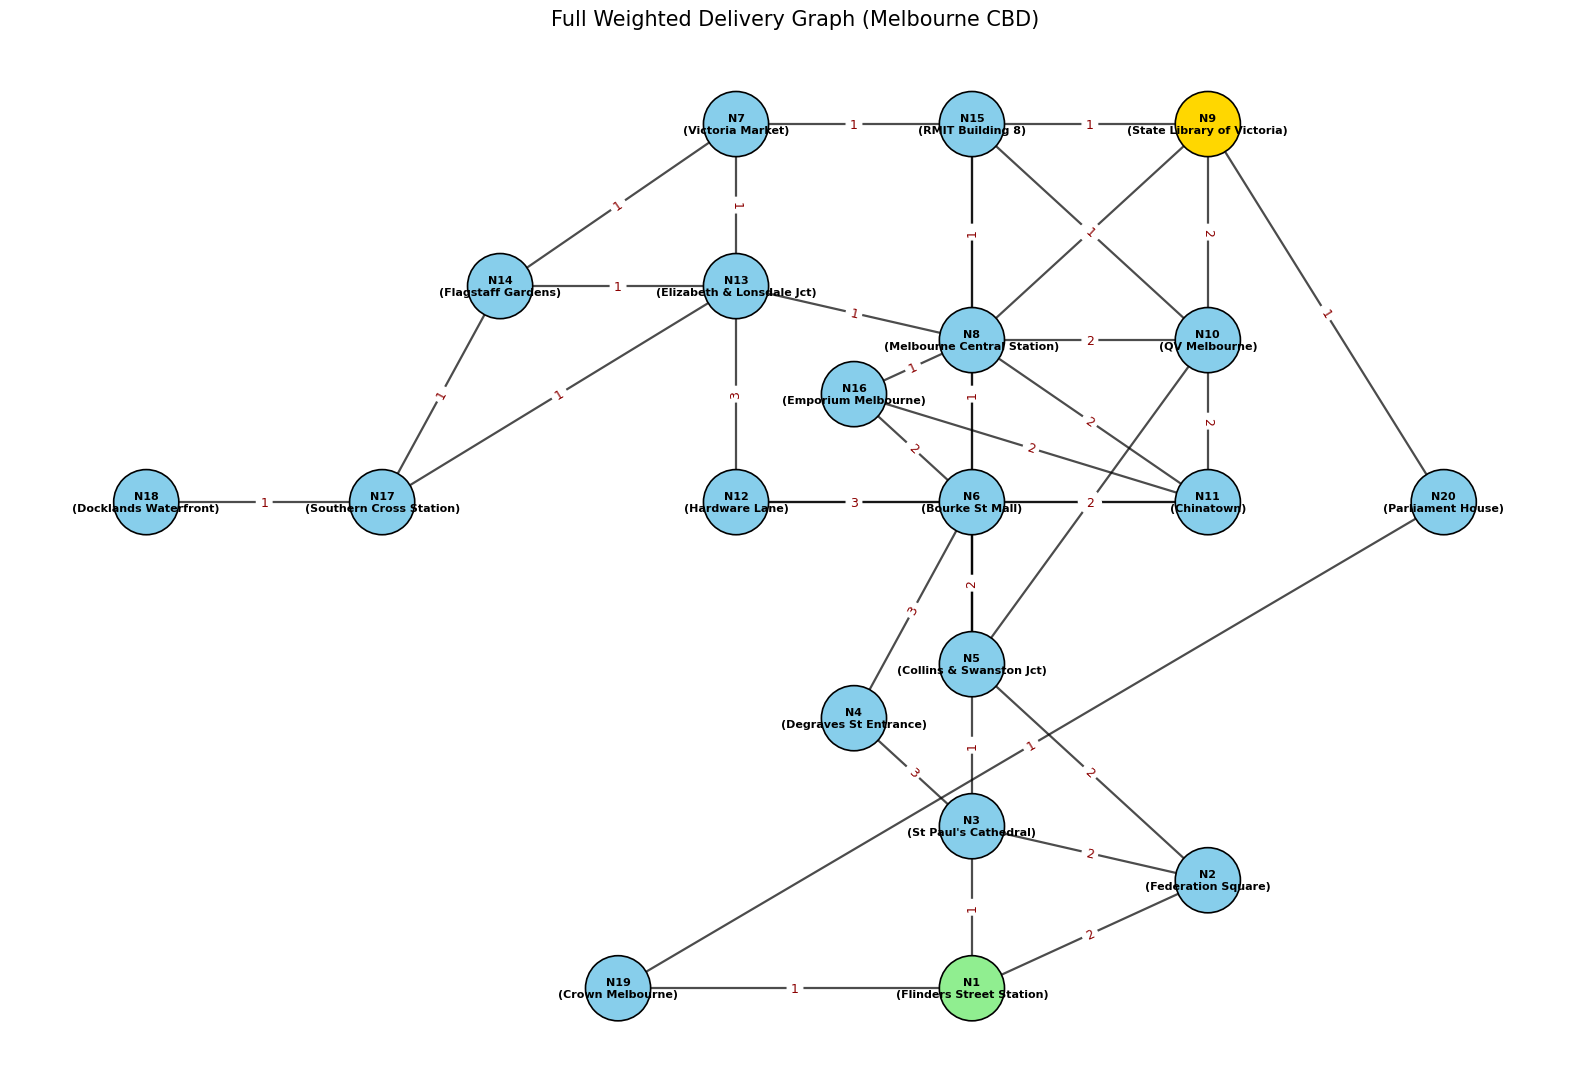

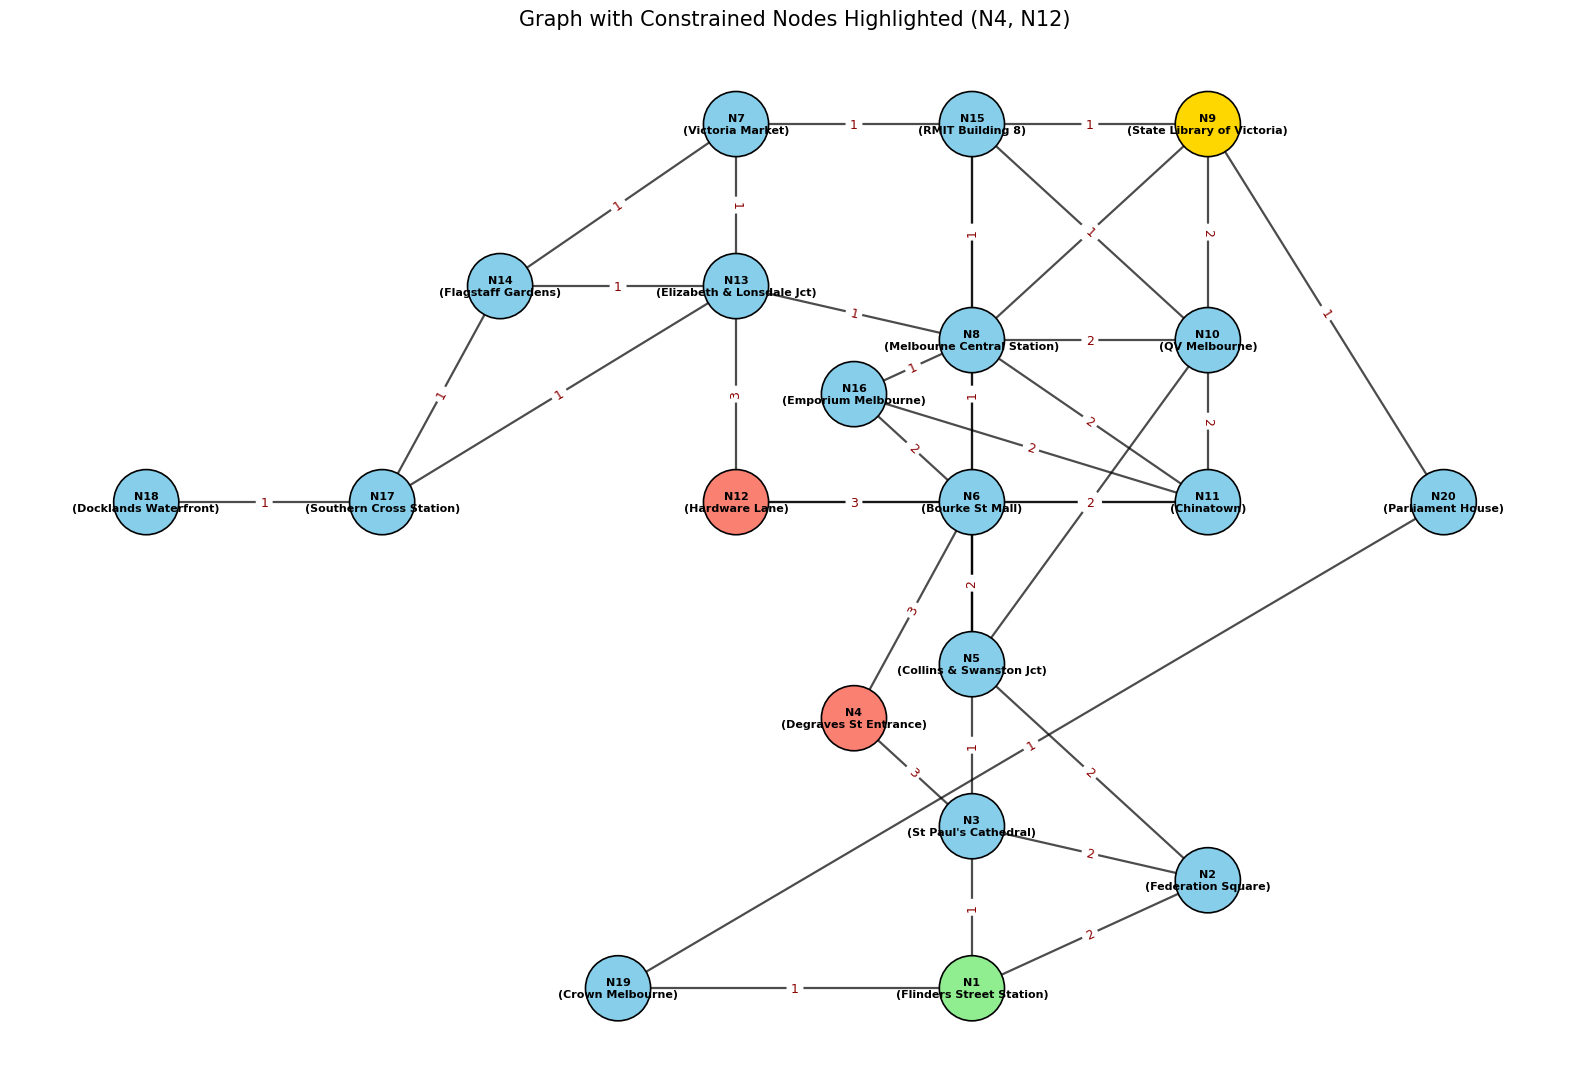

Computed shortest path: N1 -> N19 -> N20 -> N9
Total path cost: 3


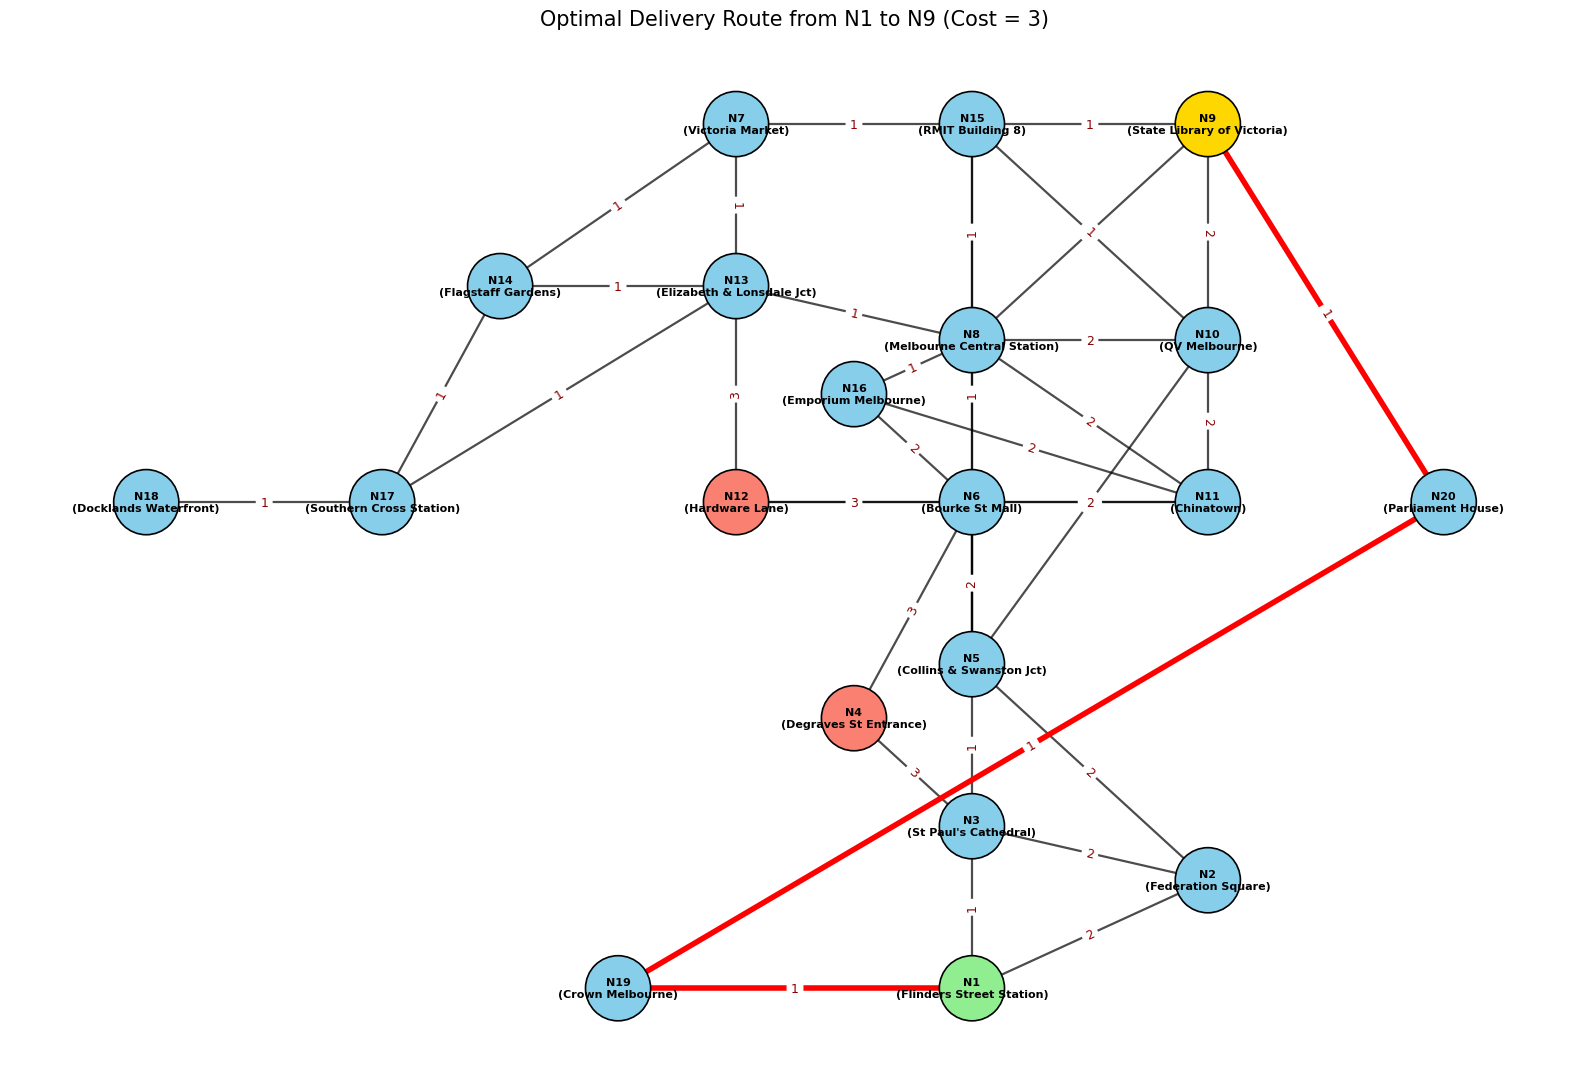


=== Weighted Shortest Path Results ===
N1 -> N9
Path: N1 -> N19 -> N20 -> N9
Total Cost: 3
--------------------------------------------------
N17 -> N10
Path: N17 -> N13 -> N8 -> N10
Total Cost: 4
--------------------------------------------------
N18 -> N15
Path: N18 -> N17 -> N13 -> N7 -> N15
Total Cost: 4
--------------------------------------------------


,Start,Goal,Weighted Path Found,Total Cost
0,N1,N9,N1 -> N19 -> N20 -> N9,3
1,N17,N10,N17 -> N13 -> N8 -> N10,4
2,N18,N15,N18 -> N17 -> N13 -> N7 -> N15,4


Saved: search_results_three_pairs.csv

=== BFS-style Results (Unweighted / Minimum Steps) ===
N1 -> N9
BFS Path: N1 -> N19 -> N20 -> N9
BFS Steps: 3
--------------------------------------------------
N17 -> N10
BFS Path: N17 -> N13 -> N8 -> N10
BFS Steps: 3
--------------------------------------------------
N18 -> N15
BFS Path: N18 -> N17 -> N13 -> N7 -> N15
BFS Steps: 4
--------------------------------------------------


,Start,Goal,BFS Path,BFS Steps
0,N1,N9,N1 -> N19 -> N20 -> N9,3
1,N17,N10,N17 -> N13 -> N8 -> N10,3
2,N18,N15,N18 -> N17 -> N13 -> N7 -> N15,4


,Start,Goal,Weighted Path Found,Total Cost,BFS Path,BFS Steps
0,N1,N9,N1 -> N19 -> N20 -> N9,3,N1 -> N19 -> N20 -> N9,3
1,N17,N10,N17 -> N13 -> N8 -> N10,4,N17 -> N13 -> N8 -> N10,3
2,N18,N15,N18 -> N17 -> N13 -> N7 -> N15,4,N18 -> N17 -> N13 -> N7 -> N15,4


Saved: search_results_comparison.csv

Explanation:
1. The graph is built as an undirected weighted graph using NetworkX.
2. Each node represents a Melbourne CBD landmark.
3. Each edge represents a feasible path segment, and the weight is the path cost.
4. Constrained nodes N4 and N12 are highlighted because they represent narrow or truck-unfriendly areas.
5. The shortest path from N1 to N9 is computed using weighted shortest path logic.
6. Three start-goal pairs are tested to support evaluation across multiple delivery scenarios.
7. BFS-style results are also shown for comparison by number of steps rather than weighted cost.


In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------
# 1. Landmark data
# Each node is a state in the delivery graph.
# -----------------------------------------
nodes = {
    "N1": "Flinders Street Station",
    "N2": "Federation Square",
    "N3": "St Paul's Cathedral",
    "N4": "Degraves St Entrance",
    "N5": "Collins & Swanston Jct",
    "N6": "Bourke St Mall",
    "N7": "Victoria Market",
    "N8": "Melbourne Central Station",
    "N9": "State Library of Victoria",
    "N10": "QV Melbourne",
    "N11": "Chinatown",
    "N12": "Hardware Lane",
    "N13": "Elizabeth & Lonsdale Jct",
    "N14": "Flagstaff Gardens",
    "N15": "RMIT Building 8",
    "N16": "Emporium Melbourne",
    "N17": "Southern Cross Station",
    "N18": "Docklands Waterfront",
    "N19": "Crown Melbourne",
    "N20": "Parliament House"
}

# -----------------------------------------
# 2. Weighted path data
# Each edge is a valid route between landmarks.
# Weight meanings:
# 1 = normal road segment
# 2 = busier inner-city segment
# 3 = constrained or less truck-friendly segment
# -----------------------------------------
edges = [
    ("N1", "N2", 2),
    ("N1", "N3", 1),
    ("N1", "N19", 1),
    ("N2", "N3", 2),
    ("N2", "N5", 2),
    ("N3", "N4", 3),
    ("N3", "N5", 1),
    ("N4", "N6", 3),
    ("N5", "N6", 2),
    ("N5", "N8", 1),
    ("N5", "N10", 1),
    ("N5", "N15", 1),
    ("N6", "N11", 2),
    ("N6", "N12", 3),
    ("N6", "N16", 2),
    ("N7", "N13", 1),
    ("N7", "N14", 1),
    ("N7", "N15", 1),
    ("N8", "N9", 1),
    ("N8", "N10", 2),
    ("N8", "N11", 2),
    ("N8", "N13", 1),
    ("N8", "N15", 1),
    ("N8", "N16", 1),
    ("N9", "N10", 2),
    ("N9", "N15", 1),
    ("N10", "N11", 2),
    ("N10", "N15", 1),
    ("N11", "N12", 3),
    ("N11", "N16", 2),
    ("N12", "N13", 3),
    ("N13", "N14", 1),
    ("N13", "N17", 1),
    ("N14", "N17", 1),
    ("N17", "N18", 1),
    ("N19", "N20", 1),
    ("N20", "N9", 1)
]

# -----------------------------------------
# 3. Manual positions for plotting
# These coordinates are only used for drawing the graph clearly.
# -----------------------------------------
pos = {
    "N1": (5, 0),
    "N19": (2, 0),
    "N2": (7, 1),
    "N3": (5, 1.5),
    "N4": (4, 2.5),
    "N5": (5, 3),
    "N6": (5, 4.5),
    "N12": (3, 4.5),
    "N11": (7, 4.5),
    "N20": (9, 4.5),
    "N17": (0, 4.5),
    "N18": (-2, 4.5),
    "N16": (4, 5.5),
    "N8": (5, 6),
    "N10": (7, 6),
    "N13": (3, 6.5),
    "N14": (1, 6.5),
    "N7": (3, 8),
    "N15": (5, 8),
    "N9": (7, 8)
}

# -----------------------------------------
# 4. Build the weighted graph
# The graph stores both connectivity and travel cost.
# -----------------------------------------
G = nx.Graph()

for node_id, landmark_name in nodes.items():
    G.add_node(node_id, name=landmark_name)

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# -----------------------------------------
# 5. Labels and key settings
# N4 and N12 are treated as constrained locations.
# -----------------------------------------
edge_labels = nx.get_edge_attributes(G, "weight")
constrained_nodes = {"N4", "N12"}
start_node = "N1"
goal_node = "N9"

node_labels = {
    node_id: f"{node_id}\n({landmark})"
    for node_id, landmark in nodes.items()
}

# -----------------------------------------
# 6. Graph drawing function
# This function is reused to create different versions
# of the same environment model for the report.
# -----------------------------------------
def draw_delivery_graph(
    graph,
    positions,
    title,
    filename,
    highlight_constrained=False,
    highlight_path=None
):
    plt.figure(figsize=(16, 11))

    node_colors = []
    for node in graph.nodes():
        if node == start_node:
            node_colors.append("lightgreen")   # Start node
        elif node == goal_node:
            node_colors.append("gold")         # Goal node
        elif highlight_constrained and node in constrained_nodes:
            node_colors.append("salmon")       # Constrained node
        else:
            node_colors.append("skyblue")      # Regular node

    # Draw all available edges first
    nx.draw_networkx_edges(
        graph,
        positions,
        width=1.6,
        alpha=0.7
    )

    # Highlight the selected path if one is provided
    if highlight_path:
        path_edges = list(zip(highlight_path[:-1], highlight_path[1:]))
        nx.draw_networkx_edges(
            graph,
            positions,
            edgelist=path_edges,
            width=4,
            edge_color="red"
        )

    # Draw landmark nodes
    nx.draw_networkx_nodes(
        graph,
        positions,
        node_size=2200,
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.2
    )

    # Add node names to make the figure easier to read
    nx.draw_networkx_labels(
        graph,
        positions,
        labels=node_labels,
        font_size=8,
        font_weight="bold"
    )

    # Show edge costs on the graph
    nx.draw_networkx_edge_labels(
        graph,
        positions,
        edge_labels=edge_labels,
        font_size=9,
        font_color="darkred"
    )

    plt.title(title, fontsize=15)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------------------
# 7. Figure 1: full weighted environment graph
# -----------------------------------------
draw_delivery_graph(
    graph=G,
    positions=pos,
    title="Full Weighted Delivery Graph (Melbourne CBD)",
    filename="1_full_weighted_graph.png",
    highlight_constrained=False
)

# -----------------------------------------
# 8. Figure 2: constrained nodes highlighted
# This helps show truck-unfriendly areas in the map.
# -----------------------------------------
draw_delivery_graph(
    graph=G,
    positions=pos,
    title="Graph with Constrained Nodes Highlighted (N4, N12)",
    filename="2_constrained_nodes.png",
    highlight_constrained=True
)

# -----------------------------------------
# 9. Figure 3: weighted shortest path from N1 to N9
# Weighted search is used here because path cost matters.
# -----------------------------------------
shortest_path = nx.shortest_path(G, source=start_node, target=goal_node, weight="weight")
shortest_cost = nx.shortest_path_length(G, source=start_node, target=goal_node, weight="weight")

print("Computed shortest path:", " -> ".join(shortest_path))
print("Total path cost:", shortest_cost)

draw_delivery_graph(
    graph=G,
    positions=pos,
    title=f"Optimal Delivery Route from {start_node} to {goal_node} (Cost = {shortest_cost})",
    filename="3_shortest_path.png",
    highlight_constrained=True,
    highlight_path=shortest_path
)

# -----------------------------------------
# 10. Test multiple start-goal pairs
# These test cases are used for evaluation in the report.
# -----------------------------------------
test_pairs = [
    ("N1", "N9"),
    ("N17", "N10"),
    ("N18", "N15")
]

print("\n=== Weighted Shortest Path Results ===")

results = []

for start, goal in test_pairs:
    # Find the minimum-cost route in the weighted graph
    path = nx.shortest_path(G, source=start, target=goal, weight="weight")
    cost = nx.shortest_path_length(G, source=start, target=goal, weight="weight")

    print(f"{start} -> {goal}")
    print("Path:", " -> ".join(path))
    print("Total Cost:", cost)
    print("-" * 50)

    results.append({
        "Start": start,
        "Goal": goal,
        "Weighted Path Found": " -> ".join(path),
        "Total Cost": cost
    })

# -----------------------------------------
# 11. Show weighted results as a table
# -----------------------------------------
df_results = pd.DataFrame(results)
display(df_results)

# -----------------------------------------
# 12. Save weighted results for later use
# -----------------------------------------
df_results.to_csv("search_results_three_pairs.csv", index=False)
print("Saved: search_results_three_pairs.csv")

# -----------------------------------------
# 13. BFS-style comparison
# This version ignores weights and focuses only on minimum steps.
# It is used as a simple uninformed comparison.
# -----------------------------------------
print("\n=== BFS-style Results (Unweighted / Minimum Steps) ===")

bfs_results = []

for start, goal in test_pairs:
    bfs_path = nx.shortest_path(G, source=start, target=goal)  # no weight
    bfs_steps = len(bfs_path) - 1

    print(f"{start} -> {goal}")
    print("BFS Path:", " -> ".join(bfs_path))
    print("BFS Steps:", bfs_steps)
    print("-" * 50)

    bfs_results.append({
        "Start": start,
        "Goal": goal,
        "BFS Path": " -> ".join(bfs_path),
        "BFS Steps": bfs_steps
    })

df_bfs = pd.DataFrame(bfs_results)
display(df_bfs)

# -----------------------------------------
# 14. Merge weighted and BFS-style results
# This combined table supports comparison in the evaluation section.
# -----------------------------------------
df_combined = pd.merge(df_results, df_bfs, on=["Start", "Goal"])
display(df_combined)

df_combined.to_csv("search_results_comparison.csv", index=False)
print("Saved: search_results_comparison.csv")

# -----------------------------------------
# 15. Short summary of what the code does
# This is useful when reviewing the notebook output.
# -----------------------------------------
print("\nExplanation:")
print("1. The graph is built as an undirected weighted graph using NetworkX.")
print("2. Each node represents a Melbourne CBD landmark.")
print("3. Each edge represents a feasible path segment, and the weight is the path cost.")
print("4. Constrained nodes N4 and N12 are highlighted because they represent narrow or truck-unfriendly areas.")
print("5. The shortest path from N1 to N9 is computed using weighted shortest path logic.")
print("6. Three start-goal pairs are tested to support evaluation across multiple delivery scenarios.")
print("7. BFS-style results are also shown for comparison by number of steps rather than weighted cost.")